# **Modeling**

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report

from scipy.stats import uniform
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [3]:
df = pd.read_csv('../data/healthcare-dataset-stroke-data-cleaned.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# Setting random seed to make data reproducible
random_seed_number = 10
np.random.seed(random_seed_number)

In [5]:
# Loading train and test variables into notebook
%store -r

In [6]:
# Verifying train and test variables are present
def func(var):
    if var in globals():
        return True

print(func('X_train'))
print(func('X_test'))
print(func('y_train'))
print(func('y_test'))

True
True
True
True


## *Initial Model*

In [8]:
# Creating an out of the box model
lr = LogisticRegression(random_state=random_seed_number)
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)
model_accuracy  = accuracy_score(y_test, y_pred)

print("The Accuracy of simple logistic regression without hyperparmeters:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple logistic regression without hyperparmeters: 0.9383561643835616


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [9]:
# Accuracy is high, but does not seem to be a good model
# Accuracy is high becuase there is a known class imbalance
# The model predicted a stroke event not occuring in all the data except one instance
np.unique(y_pred, return_counts=True)

(array([0, 1], dtype=int64), array([1021,    1], dtype=int64))

In [10]:
# Creating a balanced class model
lr_bal = LogisticRegression(class_weight='balanced', random_state=random_seed_number)
lr_bal.fit(X_train,y_train)

y_pred = lr_bal.predict(X_test)
model_accuracy  = accuracy_score(y_test, y_pred)

print("The Accuracy of simple logistic regression with class weight parameter:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple logistic regression with class weight parameter: 0.7583170254403131


              precision    recall  f1-score   support

           0       0.98      0.76      0.85       960
           1       0.17      0.76      0.28        62

    accuracy                           0.76      1022
   macro avg       0.57      0.76      0.57      1022
weighted avg       0.93      0.76      0.82      1022



In [11]:
# Accuracy decreased significantly, but improvements are seen in the precision and recall metrics
# Let's do some more hyperparameter tuning
# Some penalties are not compatiable with some solvers so three different models will be created

## *Hyperparameter Tuning with GridSearchCV*

In [13]:
# Model 1
param_grid = [
    {'penalty':['l2',None],
    'C' : np.logspace(-4,4,20),
    'solver': ['lbfgs','newton-cg','sag'],
    'max_iter': [100,1000,2500,5000]
}
]
lr_cv1 = GridSearchCV(lr_bal,param_grid = param_grid, cv = 3, verbose=True,n_jobs=-1, error_score='raise')

In [14]:
# Model 2
param_grid = [
    {'penalty':['l1','l2'],
    'C' : np.logspace(-4,4,20),
    'solver': ['liblinear'],
    'max_iter': [100,1000,2500,5000]
}
]
lr_cv2 = GridSearchCV(lr_bal,param_grid = param_grid, cv = 3, verbose=True,n_jobs=-1, error_score='raise')

In [15]:
# Model 3
param_grid = [
    {'penalty':['l1','l2','elasticnet',None],
    'C' : np.logspace(-4,4,20),
    'solver': ['saga'],
    'max_iter': [100,1000,2500,5000],
    'l1_ratio': [0.10, 0.25, 0.5, 0.75, 0.9]
}
]
lr_cv3 = GridSearchCV(lr_bal,param_grid = param_grid, cv = 3, verbose=True,n_jobs=-1, error_score='raise')

In [16]:
lr_cv1.fit(X_train,y_train)
lr_cv2.fit(X_train,y_train)
lr_cv3.fit(X_train,y_train)

Fitting 3 folds for each of 480 candidates, totalling 1440 fits
Fitting 3 folds for each of 160 candidates, totalling 480 fits
Fitting 3 folds for each of 1600 candidates, totalling 4800 fits


GridSearchCV(cv=3, error_score='raise',
             estimator=LogisticRegression(class_weight='balanced',
                                          random_state=10),
             n_jobs=-1,
             param_grid=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                          'l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': ['l1', 'l2', 'elasticnet', None],
                          'solver': ['saga']}],
             verbose=True)

In [17]:
print(lr_cv1.best_params_) 
print(lr_cv2.best_params_)
print(lr_cv3.best_params_)

{'C': 0.0001, 'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
{'C': 0.0001, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
{'C': 0.0001, 'l1_ratio': 0.1, 'max_iter': 100, 'penalty': None, 'solver': 'saga'}


In [18]:
print(f'Accuracy of model 1- : {lr_cv1.score(X_test,y_test):.5f}')
print(f'Accuracy of model 2- : {lr_cv2.score(X_test,y_test):.5f}')
print(f'Accuracy of model 3- : {lr_cv3.score(X_test,y_test):.5f}')

Accuracy of model 1- : 0.74168
Accuracy of model 2- : 0.93933
Accuracy of model 3- : 0.75832


In [19]:
y_pred1 = lr_cv1.predict(X_test)
y_pred2 = lr_cv2.predict(X_test)
y_pred3 = lr_cv3.predict(X_test)

print("*************************Model 1*************************")
print(classification_report(y_test, y_pred1))

print("*************************Model 2*************************")
print(classification_report(y_test, y_pred2))

print("*************************Model 3*************************")
print(classification_report(y_test, y_pred3))

*************************Model 1*************************
              precision    recall  f1-score   support

           0       0.98      0.74      0.84       960
           1       0.16      0.77      0.27        62

    accuracy                           0.74      1022
   macro avg       0.57      0.76      0.55      1022
weighted avg       0.93      0.74      0.81      1022

*************************Model 2*************************
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022

*************************Model 3*************************
              precision    recall  f1-score   support

           0       0.98      0.76      0.85       960
           1       0.17      0.76      0.28        62

    accu

In [20]:
# Model 2 gives similar results to the initial base model without hyperparameter tuning (precision and recall are zero for the 1 class)
# Model 1 and 3 give similar results to the logistic regression model with the class_weight parameter set to balanced
# Let's try using Random Grid Search

## *Hyperparameter Tuning with RandomizedSearchCV*

In [22]:
# Model 1
param_grid = [
    {'penalty':['l2',None],
    'C' : uniform(0, 4),
    'solver': ['lbfgs','newton-cg','sag'],
    'max_iter': [100,1000,2500,5000]
}
]
lr_rcv1 = RandomizedSearchCV(lr_bal,param_distributions = param_grid, cv = 5, verbose=True,n_jobs=-1, error_score='raise')

In [23]:
# Model 2
param_grid = [
    {'penalty':['l1','l2'],
    'C' : uniform(0, 4),
    'solver': ['liblinear'],
    'max_iter': [100,1000,2500,5000]
}
]
lr_rcv2 = RandomizedSearchCV(lr_bal,param_distributions = param_grid, cv = 5, verbose=True,n_jobs=-1, error_score='raise')

In [24]:
# Model 3
param_grid = [
    {'penalty':['l1','l2','elasticnet',None],
    'C' : uniform(0, 4),
    'solver': ['saga'],
    'max_iter': [100,1000,2500,5000],
    'l1_ratio': uniform(0, 1)
}
]
lr_rcv3 = RandomizedSearchCV(lr_bal,param_distributions = param_grid, cv = 5, verbose=True,n_jobs=-1, error_score='raise')

In [25]:
lr_rcv1.fit(X_train,y_train)
lr_rcv2.fit(X_train,y_train)
lr_rcv3.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, error_score='raise',
                   estimator=LogisticRegression(class_weight='balanced',
                                                random_state=10),
                   n_jobs=-1,
                   param_distributions=[{'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E43DE282D0>,
                                         'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E43DE2A450>,
                                         'max_iter': [100, 1000, 2500, 5000],
                                         'penalty': ['l1', 'l2', 'elasticnet',
                                                     None],
                                         'solver': ['saga']}],
                   verbose=True)

In [26]:
print(lr_rcv1.best_params_) 
print(lr_rcv2.best_params_)
print(lr_rcv3.best_params_)

{'C': 0.8991865821233906, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
{'C': 2.4041558136181775, 'max_iter': 5000, 'penalty': 'l1', 'solver': 'liblinear'}
{'C': 1.0054965368282374, 'l1_ratio': 0.5973716482308843, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}


In [27]:
print(f'Accuracy of model 1- : {lr_rcv1.score(X_test,y_test):.5f}')
print(f'Accuracy of model 2- : {lr_rcv2.score(X_test,y_test):.5f}')
print(f'Accuracy of model 3- : {lr_rcv3.score(X_test,y_test):.5f}')

Accuracy of model 1- : 0.75832
Accuracy of model 2- : 0.75832
Accuracy of model 3- : 0.75832


In [28]:
y_pred1 = lr_rcv1.predict(X_test)
y_pred2 = lr_rcv2.predict(X_test)
y_pred3 = lr_rcv3.predict(X_test)

print("*************************Model 1*************************")
print(classification_report(y_test, y_pred1))

print("*************************Model 2*************************")
print(classification_report(y_test, y_pred2))

print("*************************Model 3*************************")
print(classification_report(y_test, y_pred3))

*************************Model 1*************************
              precision    recall  f1-score   support

           0       0.98      0.76      0.85       960
           1       0.17      0.76      0.28        62

    accuracy                           0.76      1022
   macro avg       0.57      0.76      0.57      1022
weighted avg       0.93      0.76      0.82      1022

*************************Model 2*************************
              precision    recall  f1-score   support

           0       0.98      0.76      0.85       960
           1       0.17      0.76      0.28        62

    accuracy                           0.76      1022
   macro avg       0.57      0.76      0.57      1022
weighted avg       0.93      0.76      0.82      1022

*************************Model 3*************************
              precision    recall  f1-score   support

           0       0.98      0.76      0.85       960
           1       0.17      0.76      0.28        62

    accu

In [29]:
# All three models do not produce significant improvements although RandomizedSearchCV seemed to perform better

## *Verifying Results using Over-sampling Method*

In [31]:
# We will perform over-sampling to the minority class to confirm the above algorithms executed correctly
# (Under-sampling seems unnecessary since we have a low number of instances in the minority class)

In [32]:
# Creating SMOTE object
smote = SMOTE(sampling_strategy='minority', random_state=random_seed_number)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [33]:
# Fitting original model without class_weight parameter on new data
lr.fit(X_resampled,y_resampled)

y_pred = lr.predict(X_test)
model_accuracy  = accuracy_score(y_test, y_pred)

print("The Accuracy of simple logistic regression with over-sampled data:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple logistic regression with over-sampled data: 0.761252446183953


              precision    recall  f1-score   support

           0       0.98      0.76      0.86       960
           1       0.17      0.76      0.28        62

    accuracy                           0.76      1022
   macro avg       0.58      0.76      0.57      1022
weighted avg       0.93      0.76      0.82      1022



In [34]:
# A little bit better accuracy than with class_weight parameter set to 'balanced' (76.125 vs 75.832)
# Similar classification report though
# Let's rerun hyperparameter tuning using RandomizedSearchCV

## *Hyperparameter Tuning with Over-sampled Data*

In [36]:
# Model 1
param_grid = [
    {'penalty':['l2',None],
    'C' : uniform(0, 4),
    'solver': ['lbfgs','newton-cg','sag'],
    'max_iter': [100,1000,2500,5000]
}
]
lr_rcv1 = RandomizedSearchCV(lr,param_distributions = param_grid, cv = 5, verbose=True,n_jobs=-1, error_score='raise') #lr instead of lr_bal

In [37]:
# Model 2
param_grid = [
    {'penalty':['l1','l2'],
    'C' : uniform(0, 4),
    'solver': ['liblinear'],
    'max_iter': [100,1000,2500,5000]
}
]
lr_rcv2 = RandomizedSearchCV(lr,param_distributions = param_grid, cv = 5, verbose=True,n_jobs=-1, error_score='raise') #lr instead of lr_bal

In [38]:
# Model 3
param_grid = [
    {'penalty':['l1','l2','elasticnet',None],
    'C' : uniform(0, 4),
    'solver': ['saga'],
    'max_iter': [100,1000,2500,5000],
    'l1_ratio': uniform(0, 1)
}
]
lr_rcv3 = RandomizedSearchCV(lr,param_distributions = param_grid, cv = 5, verbose=True,n_jobs=-1, error_score='raise') #lr instead of lr_bal

In [39]:
lr_rcv1.fit(X_resampled,y_resampled)
lr_rcv2.fit(X_resampled,y_resampled)
lr_rcv3.fit(X_resampled,y_resampled)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, error_score='raise',
                   estimator=LogisticRegression(random_state=10), n_jobs=-1,
                   param_distributions=[{'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E43D7A7ED0>,
                                         'l1_ratio': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E43D4AC550>,
                                         'max_iter': [100, 1000, 2500, 5000],
                                         'penalty': ['l1', 'l2', 'elasticnet',
                                                     None],
                                         'solver': ['saga']}],
                   verbose=True)

In [40]:
print(lr_rcv1.best_params_) 
print(lr_rcv2.best_params_)
print(lr_rcv3.best_params_)

{'C': 3.052962348574724, 'max_iter': 100, 'penalty': 'l2', 'solver': 'sag'}
{'C': 2.3794437992332496, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
{'C': 0.7449910969918889, 'l1_ratio': 0.41379780649844733, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}


In [41]:
print(f'Accuracy of model 1- : {lr_rcv1.score(X_test,y_test):.5f}')
print(f'Accuracy of model 2- : {lr_rcv2.score(X_test,y_test):.5f}')
print(f'Accuracy of model 3- : {lr_rcv3.score(X_test,y_test):.5f}')

Accuracy of model 1- : 0.76125
Accuracy of model 2- : 0.76125
Accuracy of model 3- : 0.76125


In [42]:
y_pred1 = lr_rcv1.predict(X_test)
y_pred2 = lr_rcv2.predict(X_test)
y_pred3 = lr_rcv3.predict(X_test)

print("*************************Model 1*************************")
print(classification_report(y_test, y_pred1))

print("*************************Model 2*************************")
print(classification_report(y_test, y_pred2))

print("*************************Model 3*************************")
print(classification_report(y_test, y_pred3))

*************************Model 1*************************
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       960
           1       0.17      0.76      0.28        62

    accuracy                           0.76      1022
   macro avg       0.58      0.76      0.57      1022
weighted avg       0.93      0.76      0.82      1022

*************************Model 2*************************
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       960
           1       0.17      0.76      0.28        62

    accuracy                           0.76      1022
   macro avg       0.58      0.76      0.57      1022
weighted avg       0.93      0.76      0.82      1022

*************************Model 3*************************
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       960
           1       0.17      0.76      0.28        62

    accu

In [43]:
# No hyperparameter tuning yielded improvements
# These results seem to confirm that our algorithms performed as expected
# Need to test other models

## *Other Models without Hyperparameter Tuning*

### *Decision Tree*

In [46]:
# Creating an out of the box model
dt = DecisionTreeClassifier(random_state=random_seed_number)
dt.fit(X_train,y_train)

y_pred = dt.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)

print("The Accuracy of simple decision tree without hyperparmeters:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple decision tree without hyperparmeters: 0.8953033268101761


              precision    recall  f1-score   support

           0       0.94      0.95      0.94       960
           1       0.09      0.08      0.09        62

    accuracy                           0.90      1022
   macro avg       0.52      0.51      0.51      1022
weighted avg       0.89      0.90      0.89      1022



In [47]:
# Creating a model with the over-sampled data
dt.fit(X_resampled,y_resampled)

y_pred = lr.predict(X_test)
model_accuracy  = accuracy_score(y_test, y_pred)

print("The Accuracy of simple decision tree with over-sampled data:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple decision tree with over-sampled data: 0.761252446183953


              precision    recall  f1-score   support

           0       0.98      0.76      0.86       960
           1       0.17      0.76      0.28        62

    accuracy                           0.76      1022
   macro avg       0.58      0.76      0.57      1022
weighted avg       0.93      0.76      0.82      1022



In [48]:
# Creating a balanced class model
dt_bal = DecisionTreeClassifier(class_weight='balanced', random_state=random_seed_number)
dt_bal.fit(X_train,y_train)

y_pred = dt_bal.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)

print("The Accuracy of simple decision tree with class weight parameter:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple decision tree with class weight parameter: 0.9129158512720157


              precision    recall  f1-score   support

           0       0.94      0.97      0.95       960
           1       0.11      0.06      0.08        62

    accuracy                           0.91      1022
   macro avg       0.53      0.52      0.52      1022
weighted avg       0.89      0.91      0.90      1022



In [49]:
# The best model seems to be the model with the over-sampled data and its results are similar to our logistic regression model
# Let's try some others

### *Random Forest*

In [51]:
# Creating an out of the box model
rf = RandomForestClassifier(random_state=random_seed_number)
rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)

print("The Accuracy of simple random forest without hyperparmeters:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple random forest without hyperparmeters: 0.9383561643835616


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [52]:
# Creating a model with the over-sampled data
rf.fit(X_resampled,y_resampled)

y_pred = rf.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)

print("The Accuracy of simple random forest with over-sampled data:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple random forest with over-sampled data: 0.913894324853229


              precision    recall  f1-score   support

           0       0.94      0.97      0.95       960
           1       0.16      0.10      0.12        62

    accuracy                           0.91      1022
   macro avg       0.55      0.53      0.54      1022
weighted avg       0.90      0.91      0.90      1022



In [53]:
# Creating a balanced class model
rf_bal = RandomForestClassifier(class_weight='balanced', random_state=random_seed_number)
rf_bal.fit(X_train,y_train)

y_pred = rf_bal.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)

print("The Accuracy of simple random forest with class weight parameter:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple random forest with class weight parameter: 0.9383561643835616


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



In [54]:
# Again, no improvements
# Let's try one more

### *KNN*

In [56]:
# Creating an out of the box model
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)

print("The Accuracy of simple knn without hyperparmeters:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple knn without hyperparmeters: 0.9373776908023483


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.25      0.02      0.03        62

    accuracy                           0.94      1022
   macro avg       0.60      0.51      0.50      1022
weighted avg       0.90      0.94      0.91      1022



In [57]:
# Creating a model with over-sampled data
knn.fit(X_resampled,y_resampled)

y_pred = knn.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred)

print("The Accuracy of simple knn with over-sampled data:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of simple knn with over-sampled data: 0.8326810176125244


              precision    recall  f1-score   support

           0       0.96      0.86      0.91       960
           1       0.15      0.37      0.21        62

    accuracy                           0.83      1022
   macro avg       0.55      0.62      0.56      1022
weighted avg       0.91      0.83      0.86      1022



In [58]:
# The SMOTE object used to created the over-sampled data uses an algorithm similar to knn
# Let's explore this further with some hyperparameter tuning, and work on implementing a pipeline

### *KNN with Hyperparameter Tuning*

In [60]:
# Recombining train and test variables for ease of use later
X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

In [61]:
# Creating steps for pipeline
steps = [('over-sample', SMOTE(sampling_strategy='minority', random_state=random_seed_number)), ('model', KNeighborsClassifier())]

# Pipeline object
pipeline = Pipeline(steps=steps)

# Using StratifiedKFold to create folds for cross-validation
cv = StratifiedKFold()

# Extracting indices
cv1, cv2, cv3, cv4, cv5 = cv.split(X, y)

# Gathering test data
y_test1 = y[cv1[1]]
y_test2 = y[cv2[1]]
y_test3 = y[cv3[1]]
y_test4 = y[cv4[1]]
y_test5 = y[cv5[1]]
y_test_cv = np.concatenate((y_test1, y_test2, y_test3, y_test4, y_test5))

# Gathering predictions
y_pred = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)

# Calculating metrics
model_accuracy = accuracy_score(y_test_cv, y_pred)
print("The Accuracy of pipeline using simple knn:",model_accuracy)
print("\n")
print(classification_report(y_test_cv, y_pred))

The Accuracy of pipeline using simple knn: 0.8166340508806262


              precision    recall  f1-score   support

           0       0.96      0.84      0.90      4861
           1       0.10      0.37      0.16       249

    accuracy                           0.82      5110
   macro avg       0.53      0.60      0.53      5110
weighted avg       0.92      0.82      0.86      5110



In [62]:
# Results are similar to the base model using over-sampled data without cross-validation
# We can proceed with confidence that our pipeline is configued correctly

In [63]:
# Recombining resampled train and test variables to fit our model on similar to what our pipeline would do
X_smote = np.concatenate((X_resampled, X_test))
y_smote = np.concatenate((y_resampled, y_test))

param_grid = {'n_neighbors':np.arange(1,50)}
knn_cv = GridSearchCV(knn, param_grid, cv=cv, verbose=True, n_jobs=-1, error_score='raise')
knn_cv.fit(X_smote, y_smote)

print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Best Score:0.9541004541571114
Best Parameters: {'n_neighbors': 2}


In [64]:
# Defining the optimal number of neighbors found in previous step
steps = [('over-sample', SMOTE(sampling_strategy='minority', random_state=random_seed_number)), ('model', KNeighborsClassifier(n_neighbors=2))]
pipeline = Pipeline(steps=steps)
cv = StratifiedKFold()

cv1, cv2, cv3, cv4, cv5 = cv.split(X, y)

y_test1 = y[cv1[1]]
y_test2 = y[cv2[1]]
y_test3 = y[cv3[1]]
y_test4 = y[cv4[1]]
y_test5 = y[cv5[1]]
y_test = np.concatenate((y_test1, y_test2, y_test3, y_test4, y_test5))

y_pred = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)
model_accuracy = accuracy_score(y_test, y_pred)
print("The Accuracy of pipeline using knn with hyperparameter tuning:",model_accuracy)
print("\n")
print(classification_report(y_test, y_pred))

The Accuracy of pipeline using knn with hyperparameter tuning: 0.8964774951076321


              precision    recall  f1-score   support

           0       0.96      0.93      0.94      4861
           1       0.11      0.16      0.13       249

    accuracy                           0.90      5110
   macro avg       0.53      0.55      0.54      5110
weighted avg       0.91      0.90      0.91      5110



In [65]:
# The results are still disappointing
# Let's leverage a library that calculates all this work for us

## *PyCaret to Further Verfiy our Results*

In [67]:
# import ClassificationExperiment and init the class
from pycaret.classification import ClassificationExperiment
exp = ClassificationExperiment()

# init setup on exp
exp.setup(df, target = 'stroke', session_id = 123)

,Description,Value
0,Session id,123
1,Target,stroke
2,Target type,Binary
3,Original data shape,"(5110, 12)"
4,Transformed data shape,"(5110, 21)"
5,Transformed train set shape,"(3577, 21)"
6,Transformed test set shape,"(1533, 21)"
7,Numeric features,6
8,Categorical features,5
9,Preprocess,True


In [68]:
# compare baseline models
best = exp.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.9514,0.8349,0.0000,0.0000,0.0000,0.0000,0.0000,0.0800
rf,Random Forest Classifier,0.9514,0.8053,0.0000,0.0000,0.0000,0.0000,0.0000,0.3230
dummy,Dummy Classifier,0.9514,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0850
lr,Logistic Regression,0.9511,0.8400,0.0056,0.1000,0.0105,0.0090,0.0206,2.0970
knn,K Neighbors Classifier,0.9511,0.5325,0.0056,0.1000,0.0105,0.0090,0.0206,1.4280
catboost,CatBoost Classifier,0.9494,0.8126,0.0173,0.2200,0.0307,0.0247,0.0495,2.8200
ada,Ada Boost Classifier,0.9491,0.8082,0.0343,0.3500,0.0607,0.0516,0.0928,0.1790
et,Extra Trees Classifier,0.9488,0.7606,0.0340,0.2333,0.0591,0.0495,0.0743,0.2700
lightgbm,Light Gradient Boosting Machine,0.9480,0.8129,0.0569,0.4333,0.0962,0.0832,0.1338,1.1930
gbc,Gradient Boosting Classifier,0.9458,0.8238,0.0170,0.1000,0.0286,0.0166,0.0231,0.3530


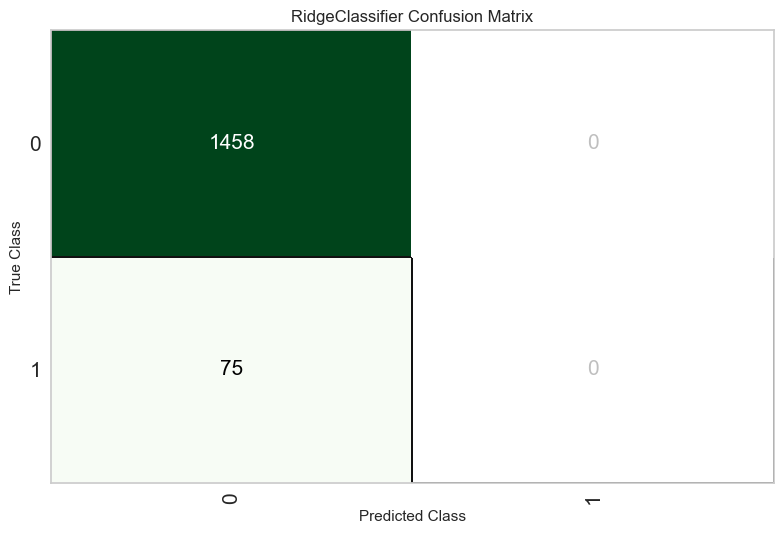

In [69]:
exp.plot_model(best, plot = 'confusion_matrix')

In [70]:
# This is similar to our initial logistic regression model created at the very beginning of this notebook
# Accuracy is high only becuase all the data was predicted to belong to class 0
# Let's see if other high performing models act similarly

In [71]:
recall = exp.compare_models(sort='Recall')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.5475,0.6869,0.5895,0.0805,0.1184,0.0484,0.0807,0.0850
nb,Naive Bayes,0.9147,0.8264,0.1944,0.1760,0.1809,0.1369,0.1387,0.0820
dt,Decision Tree Classifier,0.9036,0.5510,0.1605,0.1280,0.1415,0.0918,0.0926,0.0920
svm,SVM - Linear Kernel,0.8561,0.5356,0.1114,0.1384,0.0302,0.0101,0.0227,0.0860
lda,Linear Discriminant Analysis,0.9444,0.8348,0.0683,0.2333,0.1044,0.0858,0.1036,0.0830
lightgbm,Light Gradient Boosting Machine,0.9480,0.8129,0.0569,0.4333,0.0962,0.0832,0.1338,1.1750
ada,Ada Boost Classifier,0.9491,0.8082,0.0343,0.3500,0.0607,0.0516,0.0928,0.1710
et,Extra Trees Classifier,0.9488,0.7606,0.0340,0.2333,0.0591,0.0495,0.0743,0.2730
catboost,CatBoost Classifier,0.9494,0.8126,0.0173,0.2200,0.0307,0.0247,0.0495,2.7460
gbc,Gradient Boosting Classifier,0.9458,0.8238,0.0170,0.1000,0.0286,0.0166,0.0231,0.3580


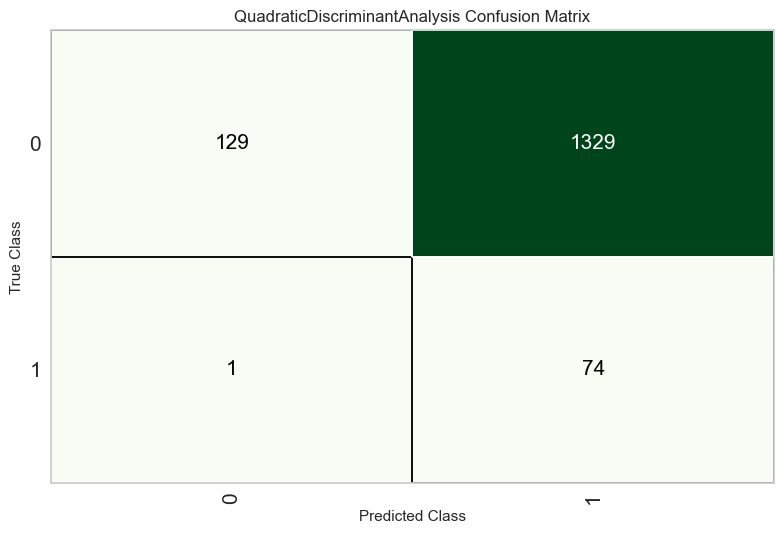

In [72]:
exp.plot_model(recall, plot = 'confusion_matrix')

In [73]:
# Confusion matrix is promising, but accuracy is low
# Let's try the model with the highest precision

In [74]:
precision = exp.compare_models(sort='Precision')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9480,0.8129,0.0569,0.4333,0.0962,0.0832,0.1338,1.1730
ada,Ada Boost Classifier,0.9491,0.8082,0.0343,0.3500,0.0607,0.0516,0.0928,0.1810
lda,Linear Discriminant Analysis,0.9444,0.8348,0.0683,0.2333,0.1044,0.0858,0.1036,0.0900
et,Extra Trees Classifier,0.9488,0.7606,0.0340,0.2333,0.0591,0.0495,0.0743,0.2650
catboost,CatBoost Classifier,0.9494,0.8126,0.0173,0.2200,0.0307,0.0247,0.0495,2.7950
nb,Naive Bayes,0.9147,0.8264,0.1944,0.1760,0.1809,0.1369,0.1387,0.0840
svm,SVM - Linear Kernel,0.8561,0.5356,0.1114,0.1384,0.0302,0.0101,0.0227,0.0900
dt,Decision Tree Classifier,0.9036,0.5510,0.1605,0.1280,0.1415,0.0918,0.0926,0.0760
lr,Logistic Regression,0.9511,0.8400,0.0056,0.1000,0.0105,0.0090,0.0206,0.2730
knn,K Neighbors Classifier,0.9511,0.5325,0.0056,0.1000,0.0105,0.0090,0.0206,0.1100


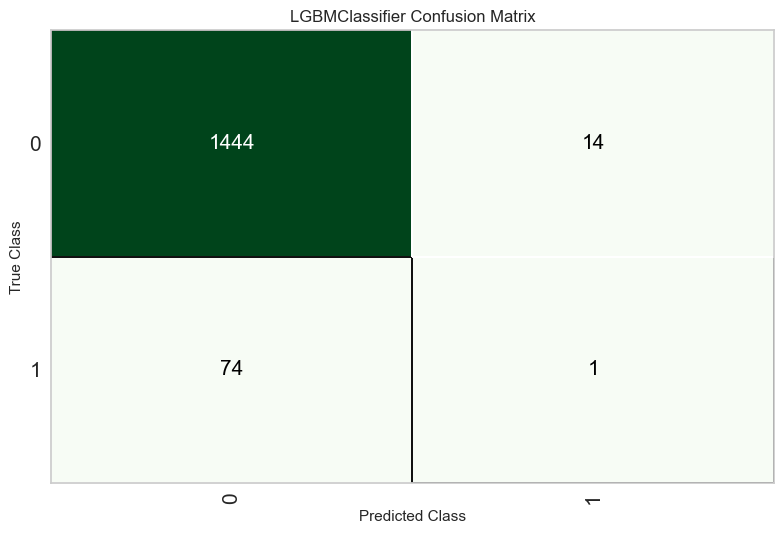

In [75]:
exp.plot_model(precision, plot = 'confusion_matrix')

In [76]:
# Better results, but still not a very high precision score to be satisfied
# Let's try one more by F1 score

In [77]:
f1 = exp.compare_models(sort='F1')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.9147,0.8264,0.1944,0.1760,0.1809,0.1369,0.1387,0.0800
dt,Decision Tree Classifier,0.9036,0.5510,0.1605,0.1280,0.1415,0.0918,0.0926,0.0800
qda,Quadratic Discriminant Analysis,0.5475,0.6869,0.5895,0.0805,0.1184,0.0484,0.0807,0.0760
lda,Linear Discriminant Analysis,0.9444,0.8348,0.0683,0.2333,0.1044,0.0858,0.1036,0.0910
lightgbm,Light Gradient Boosting Machine,0.9480,0.8129,0.0569,0.4333,0.0962,0.0832,0.1338,1.2320
ada,Ada Boost Classifier,0.9491,0.8082,0.0343,0.3500,0.0607,0.0516,0.0928,0.1890
et,Extra Trees Classifier,0.9488,0.7606,0.0340,0.2333,0.0591,0.0495,0.0743,0.2730
catboost,CatBoost Classifier,0.9494,0.8126,0.0173,0.2200,0.0307,0.0247,0.0495,2.4040
svm,SVM - Linear Kernel,0.8561,0.5356,0.1114,0.1384,0.0302,0.0101,0.0227,0.0880
gbc,Gradient Boosting Classifier,0.9458,0.8238,0.0170,0.1000,0.0286,0.0166,0.0231,0.3970


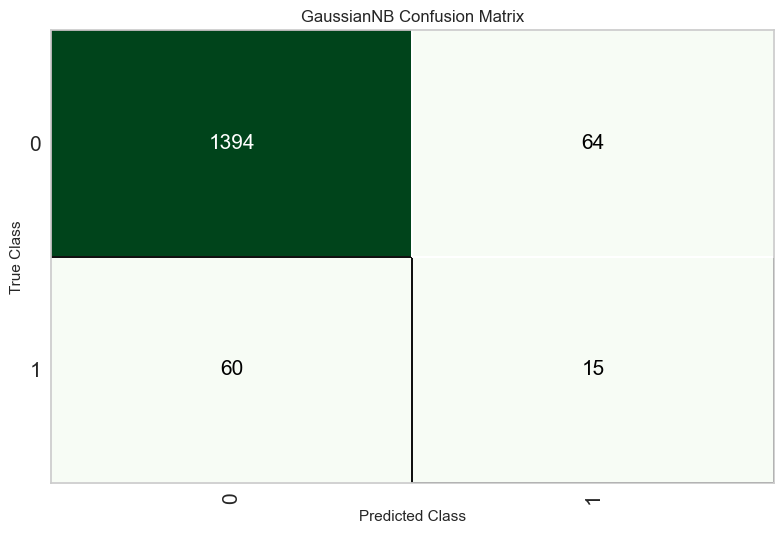

In [78]:
exp.plot_model(f1, plot = 'confusion_matrix')

In [79]:
# Again, better results from confusion matrix, but precision and recall are pitifull

In [80]:
# We can conclude that data is not sufficient

In [81]:
# Remove all variables from storage
# %store -z